In [2]:
print("hi")


hi


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load prices (instruments as columns, days as rows)
df = pd.read_csv("prices.txt", sep=r"\s+", header=0)
df.head()


ModuleNotFoundError: No module named 'matplotlib'

In [4]:
pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 8.9 MB/s  0:00:01 eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.3 MB/s  0:00:00 11.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 11.6 MB/s  0:00:00a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load prices (instruments as columns, days as rows)
df = pd.read_csv("prices.txt", sep=r"\s+", header=0)
df.head()


Matplotlib is building the font cache; this may take a moment.


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


(500, 51)
['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT', 'HUXZ', 'DUCT', 'SMAH', 'NPCK', 'MSDP', 'EORC', 'CUBO', 'HRET', 'ANSO', 'DIHO', 'RTTH', 'SPLZ', 'NWIG', 'MMBT', 'MDGI', 'AGVF', 'RRES', 'CTGI', 'ALUT', 'ACAC', 'SRTX', 'GARI', 'RCRI', 'ACIX', 'CCNS', 'MTNS', 'IHOZ', 'NAYO', 'FWWG', 'EELT', 'HRND', 'AETS', 'ULXY', 'BLBT', 'BENI', 'ITPA', 'HTRK', 'NGTE', 'ILVX', 'FCSG', 'FARS', 'MHRM', 'EAFC']


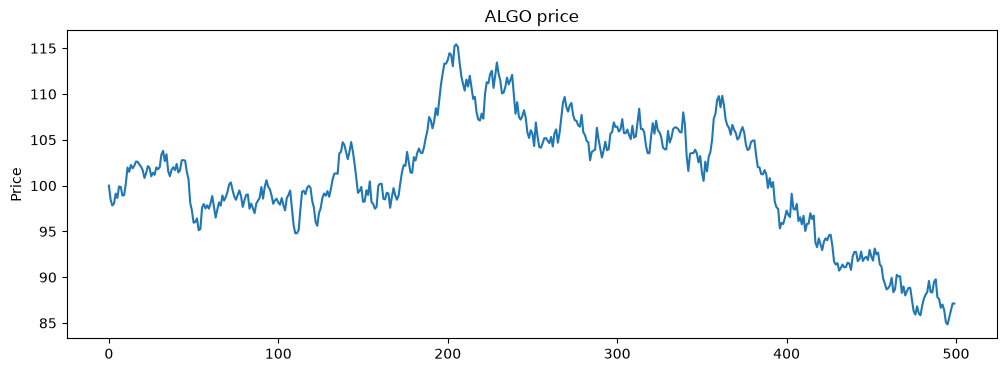

In [6]:
# Basic info
print(df.shape)        # (days, instruments)
print(df.columns.tolist())  # ticker names

# Summary stats
df.describe()

# Look at a specific stock
df["ALGO"].head(10)

# Plot one instrument over time
df["ALGO"].plot(figsize=(12, 4), title="ALGO price")
plt.ylabel("Price")
plt.show()


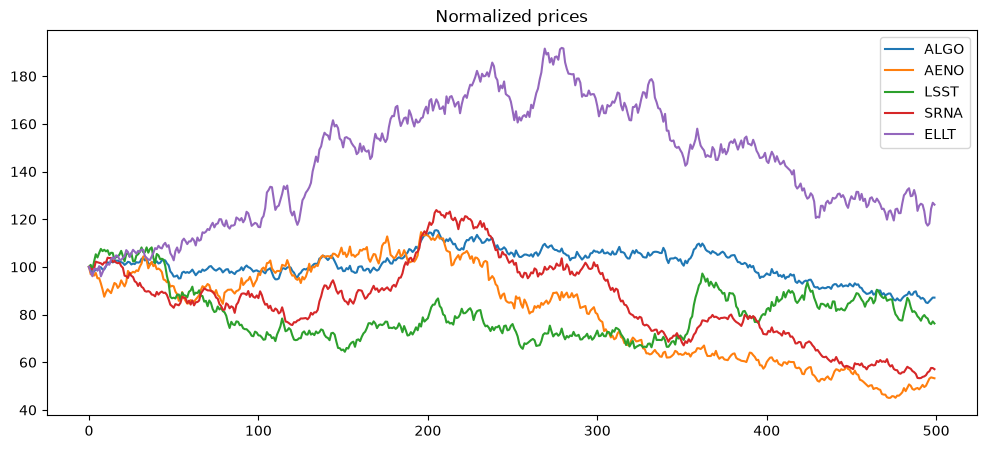

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("prices.txt", sep=r"\s+", header=0)

# Normalize to 100 at start — easier to compare than raw prices
norm = df / df.iloc[0] * 100
norm[["ALGO", "AENO", "LSST", "SRNA", "ELLT"]].plot(figsize=(12, 5), title="Normalized prices")
plt.show()


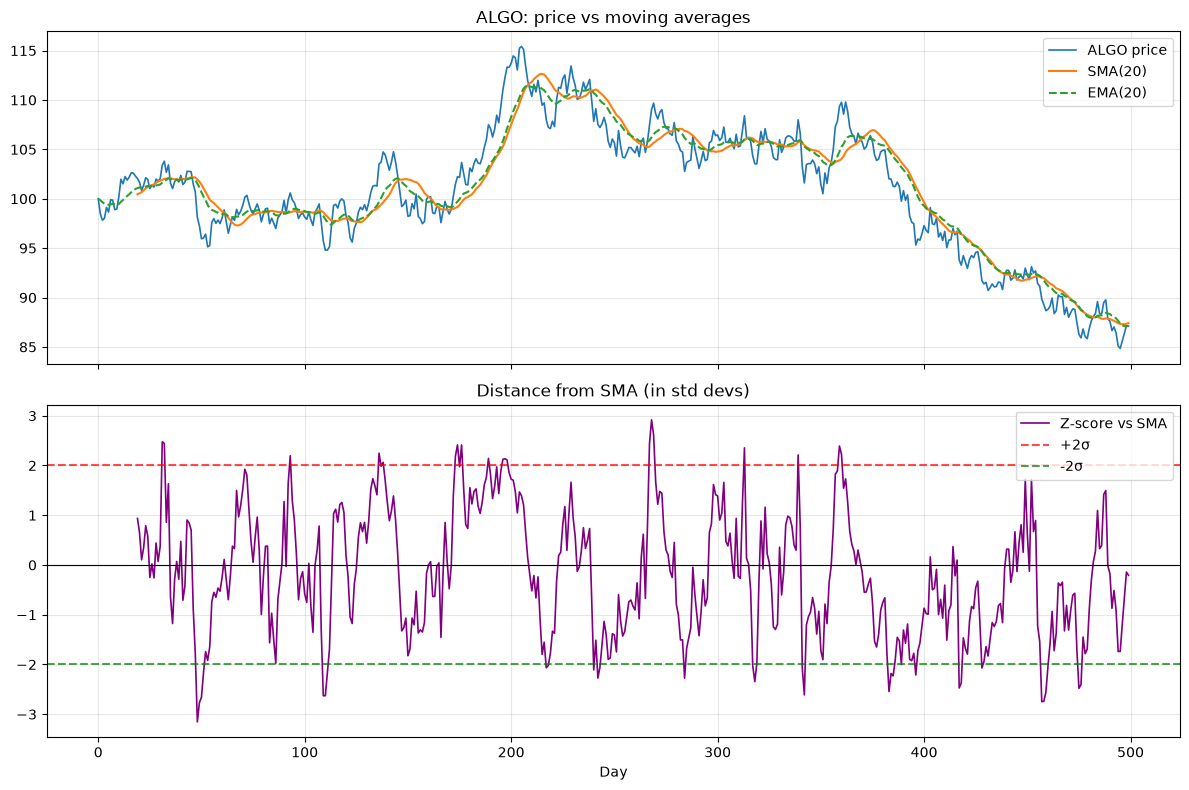

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- settings ---
TICKER = "ALGO"   # change to any column name
SMA_WINDOW = 20
EMA_WINDOW = 20

# --- load data ---
df = pd.read_csv("prices.txt", sep=r"\s+", header=0)
price = df[TICKER]

# --- moving averages ---
sma = price.rolling(SMA_WINDOW).mean()
ema = price.ewm(span=EMA_WINDOW, adjust=False).mean()

# mean-reversion distance from SMA
spread = price - sma
zscore = spread / price.rolling(SMA_WINDOW).std()

# --- plot 1: price vs SMA & EMA ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(price, label=f"{TICKER} price", linewidth=1.2)
axes[0].plot(sma, label=f"SMA({SMA_WINDOW})", linewidth=1.5)
axes[0].plot(ema, label=f"EMA({EMA_WINDOW})", linewidth=1.5, linestyle="--")
axes[0].set_title(f"{TICKER}: price vs moving averages")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- plot 2: z-score (mean reversion signal) ---
axes[1].plot(zscore, color="purple", linewidth=1.2, label="Z-score vs SMA")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(2, color="red", linestyle="--", alpha=0.7, label="+2σ")
axes[1].axhline(-2, color="green", linestyle="--", alpha=0.7, label="-2σ")
axes[1].set_title("Distance from SMA (in std devs)")
axes[1].set_xlabel("Day")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
from indicators import load_prices, log_returns, sharpe_ratio, sharpe_ratio_per_instrument

df = load_prices()
rets = log_returns(df).iloc[-250:]   # test window

summary = pd.DataFrame({
    "avg_daily_ret": rets.mean(),           # direction: long vs short
    "sharpe": sharpe_ratio_per_instrument(df, last_n_days=250),
})
summary

,avg_daily_ret,sharpe
ALGO,-0.000786,-1.198147
AENO,-0.001877,-1.571828
LSST,0.000052,0.009121
SRNA,-0.002331,-2.388498
ELLT,-0.001178,-1.002769
AMRP,0.000743,0.439125
OTCS,0.001554,0.870627
HETT,-0.000486,-0.513881
HUXZ,-0.002524,-1.726477
DUCT,-0.001782,-1.486905


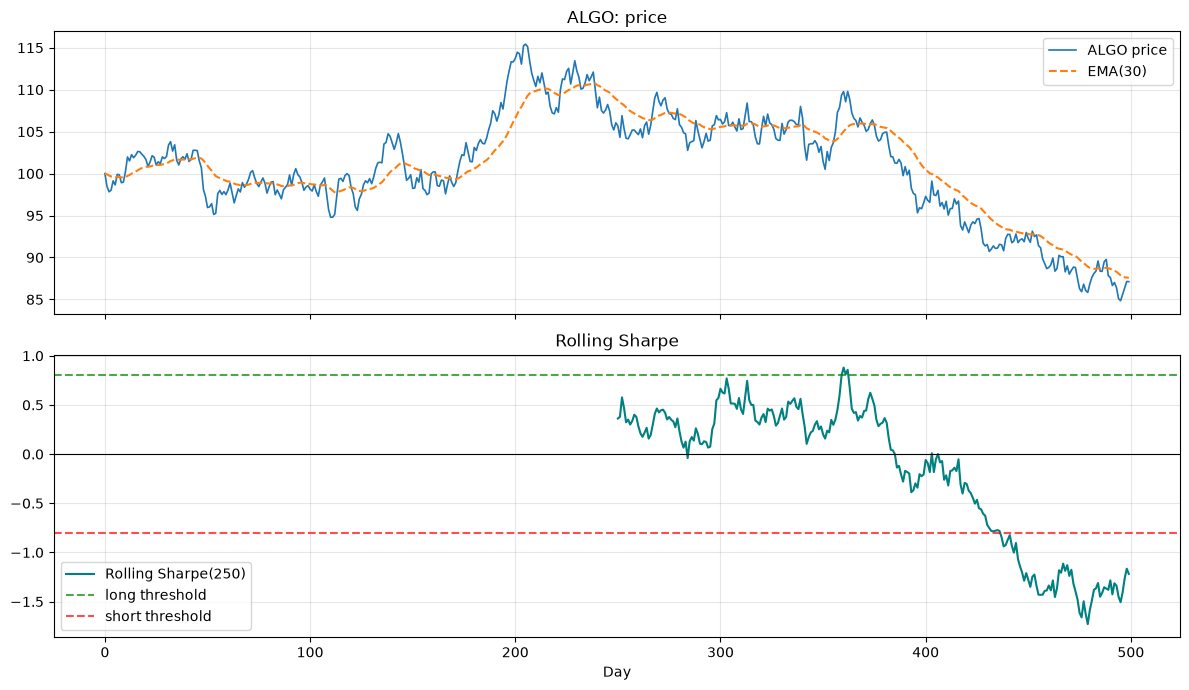

ALGO Sharpe (last 250 days): -1.22


In [20]:
import importlib
import indicators
importlib.reload(indicators)

from indicators import load_prices, plot_price_and_sharpe, sharpe_ratio, log_returns

df = load_prices()
ticker = "ALGO"

plot_price_and_sharpe(df, ticker=ticker, sharpe_window=250)


print(f"{ticker} Sharpe (last 250 days): {sharpe_ratio(log_returns(df[ticker]).iloc[-250:]):.2f}")